## Cual es el objetivo?

- https://matplotlib.org/stable/plot_types/basic/index.html
- https://seaborn.pydata.org/examples/index.html
- https://plotly.com/python/basic-charts/
- https://python-visualization.github.io/folium/version-v0.9.1/quickstart.html#Vincent/Vega-and-Altair/VegaLite-Markers

## Instalar librerias

In [ ]:
!pip install matplotlib seaborn folium plotly

## Importar Librerias

In [1]:
import matplotlib.pyplot as plt ## Gráficos Matplotlib
import seaborn as sns ## Gráficos Seaborn
import folium ## MAPAS
import plotly.express as px ## Graficos Interactivos
import pandas as pd
import numpy as np
from urllib.request import urlopen
import json

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
pizza_data = pd.read_excel('/content/drive/MyDrive/Data Science BIT 202508/Clases/Clase 10 - Visualización de datos/Enhanced_pizza_sell_data_2024-25.xlsx')
pizza_data.head()

,Order ID,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Pizza Size,Pizza Type,Toppings Count,Distance (km),...,Topping Density,Order Month,Payment Category,Estimated Duration (min),Delay (min),Is Delayed,Pizza Complexity,Traffic Impact,Order Hour,Restaurant Avg Time
0,ORD001,Domino's,"New York, NY",2024-01-05 18:30:00,2024-01-05 18:45:00,15,Medium,Veg,3,2.5,...,1.200000,January,Online,6.0,9.0,False,6,2,18,30.259434
1,ORD002,Papa John's,"Los Angeles, CA",2024-02-14 20:00:00,2024-02-14 20:25:00,25,Large,Non-Veg,4,5.0,...,0.800000,February,Online,12.0,13.0,False,12,3,20,28.186275
2,ORD003,Little Caesars,"Chicago, IL",2024-03-21 12:15:00,2024-03-21 12:35:00,20,Small,Vegan,2,3.0,...,0.666667,March,Online,7.2,12.8,False,2,1,12,28.844221
3,ORD004,Pizza Hut,"Miami, FL",2024-04-10 19:45:00,2024-04-10 20:10:00,25,XL,Cheese Burst,5,4.5,...,1.111111,April,Offline,10.8,14.2,False,20,2,19,29.948454
4,ORD005,Marco's Pizza,"Dallas, TX",2024-05-05 13:00:00,2024-05-05 13:20:00,20,Medium,Non-Veg,3,2.0,...,1.500000,May,Online,4.8,15.2,False,6,3,13,30.286458


In [ ]:
pizza_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004 entries, 0 to 1003
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Order ID                      1004 non-null   object        
 1   Restaurant Name               1004 non-null   object        
 2   Location                      1004 non-null   object        
 3   Order Time                    1004 non-null   datetime64[ns]
 4   Delivery Time                 1004 non-null   datetime64[ns]
 5   Delivery Duration (min)       1004 non-null   int64         
 6   Pizza Size                    1004 non-null   object        
 7   Pizza Type                    1004 non-null   object        
 8   Toppings Count                1004 non-null   int64         
 9   Distance (km)                 1004 non-null   float64       
 10  Traffic Level                 1004 non-null   object        
 11  Payment Method                

In [ ]:
pizza_data['Order Month Year'] = pizza_data['Order Time'].dt.to_period('M').astype(str)
pizza_data[['Order Time','Order Month Year']]

,Order Time,Order Month Year
0,2024-01-05 18:30:00,2024-01
1,2024-02-14 20:00:00,2024-02
2,2024-03-21 12:15:00,2024-03
3,2024-04-10 19:45:00,2024-04
4,2024-05-05 13:00:00,2024-05
...,...,...
999,2026-07-03 19:00:00,2026-07
1000,2026-07-04 20:15:00,2026-07
1001,2026-07-05 18:30:00,2026-07
1002,2026-07-06 19:45:00,2026-07


## Matplotlib

### Gráfica de linea

In [ ]:
pizza_data['Order Time'] = pd.to_datetime(pizza_data['Order Time'])

avg_delivery = (
    pizza_data.groupby(pizza_data['Order Time'].dt.to_period('M'))['Delivery Duration (min)']
    .mean()
    .reset_index()
)
avg_delivery['Order Time'] = avg_delivery['Order Time'].dt.to_timestamp()

avg_delivery

,Order Time,Delivery Duration (min)
0,2024-01-01,22.307692
1,2024-02-01,22.666667
2,2024-03-01,21.875000
3,2024-04-01,22.096774
4,2024-05-01,21.666667
5,2024-06-01,22.272727
6,2024-07-01,22.741935
7,2024-08-01,28.837209
8,2024-09-01,28.533333
9,2024-10-01,29.431818


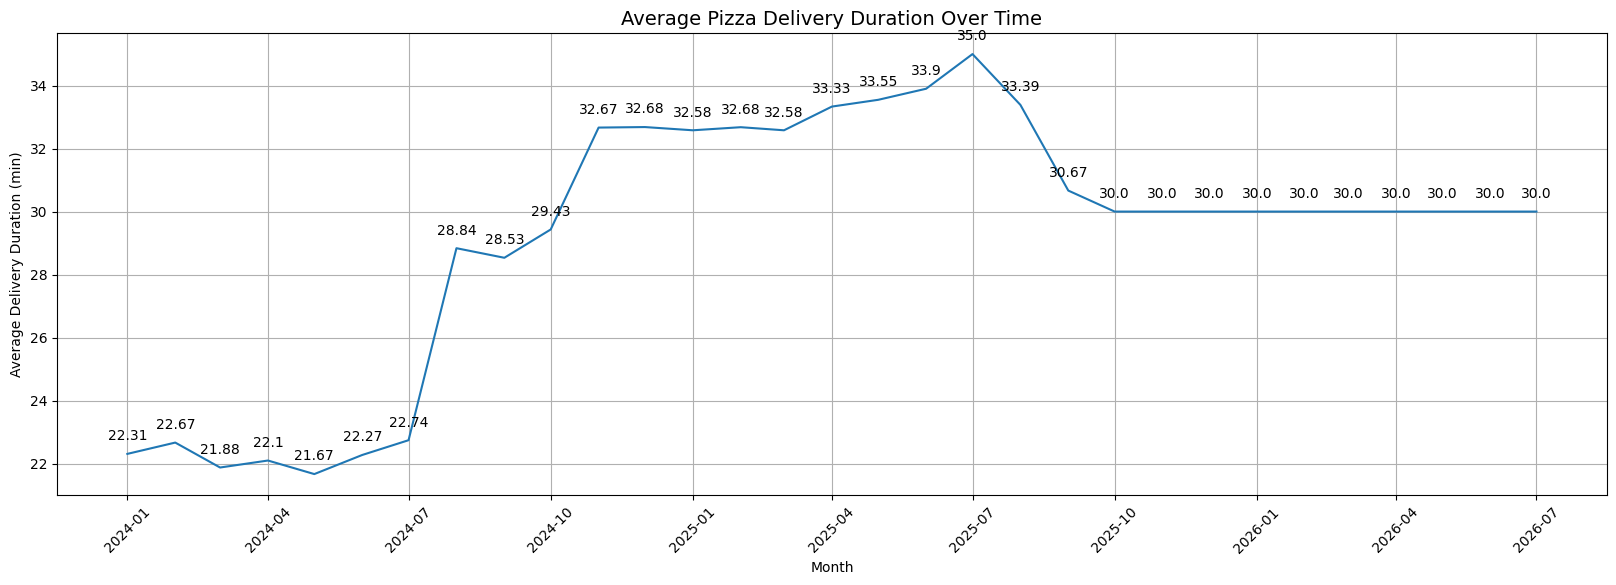

In [ ]:
plt.figure(figsize=(20,6))  ## Ancho, Largo
plt.plot(avg_delivery['Order Time'], avg_delivery['Delivery Duration (min)'])

for i, (xi, yi) in enumerate(zip(avg_delivery['Order Time'], avg_delivery['Delivery Duration (min)'],)):
    plt.annotate(f'{round(yi,2)}', (xi, yi), textcoords="offset points", xytext=(0, 10), ha='center')

plt.title('Average Pizza Delivery Duration Over Time', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Delivery Duration (min)')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [ ]:
pizza_data['Order Month Year']

,Order Month Year
0,2024-01
1,2024-02
2,2024-03
3,2024-04
4,2024-05
...,...
999,2026-07
1000,2026-07
1001,2026-07
1002,2026-07


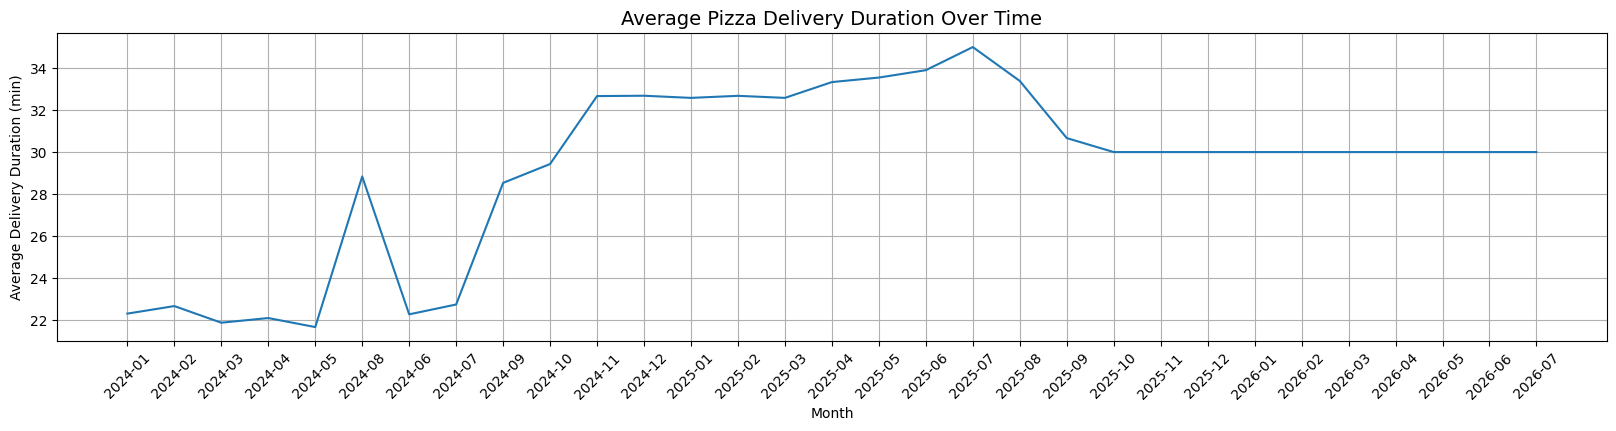

In [ ]:
plt.figure(figsize=(20,4))  ## Ancho, Largo
sns.lineplot(
    data=pizza_data,
    x='Order Month Year',
    y='Delivery Duration (min)',
    estimator = 'mean',
    errorbar=None
)
plt.title('Average Pizza Delivery Duration Over Time', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Delivery Duration (min)')
plt.xticks(rotation=45)
plt.grid()
plt.show()

### Gráfica de barras

In [ ]:
pizza_data['Restaurant Name'].value_counts()

,count
Restaurant Name,
Domino's,212
Papa John's,204
Little Caesars,199
Pizza Hut,194
Marco's Pizza,192
Marco’s Pizza,3


In [ ]:
pizza_data['Restaurant Name'] = pizza_data['Restaurant Name'].str.replace('Marco’s Pizza',"Marco's Pizza")

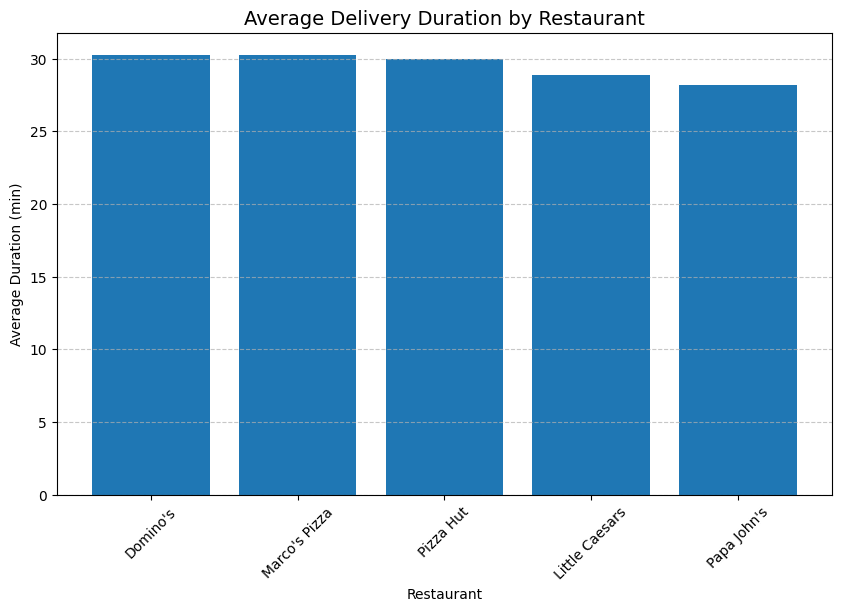

In [ ]:
avg_by_restaurant = (
    pizza_data.groupby('Restaurant Name')['Delivery Duration (min)']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
plt.bar(avg_by_restaurant.index, avg_by_restaurant.values)
#avg_by_restaurant.plot(kind='bar', color='teal')
plt.title('Average Delivery Duration by Restaurant', fontsize=14)
plt.xlabel('Restaurant')
plt.ylabel('Average Duration (min)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


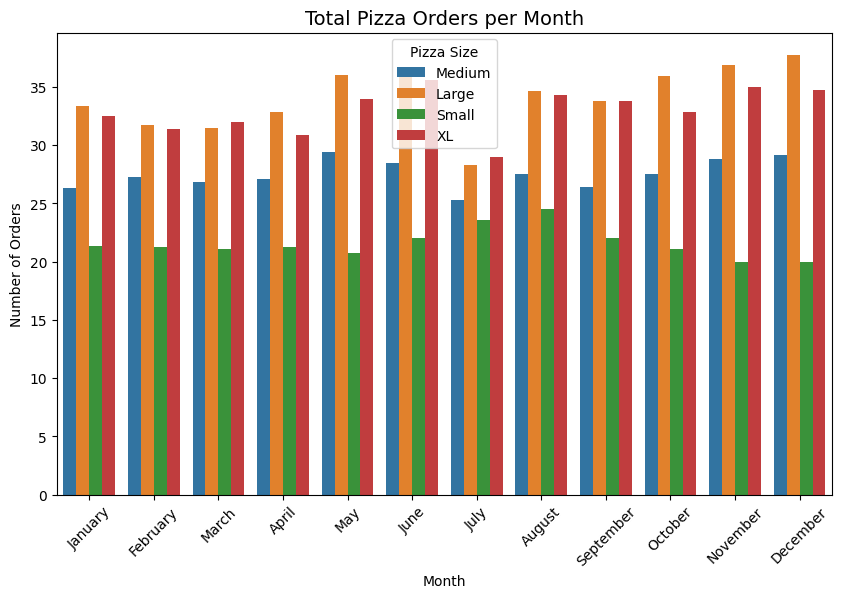

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=pizza_data,
    x='Order Month',
    order=[
        'January','February','March','April','May','June','July',
        'August','September','October','November','December'
    ],
    y='Delivery Duration (min)',
    hue='Pizza Size',
    estimator='mean',
    errorbar=None
)
plt.title('Total Pizza Orders per Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

In [ ]:
avg_delay = (
    pizza_data.groupby(['Pizza Size'])['Delay (min)']
    .mean()
    .reset_index()
    .sort_values(by='Delay (min)', ascending=False)
)

fig = px.bar(
    avg_delay,
    x='Pizza Size',
    y='Delay (min)',
    hover_data=['Delay (min)'],
    #text=avg_delay['Delay (min)'].round(1),
    title='Average Delivery Delay by Pizza Size and Type',
    color_discrete_sequence=px.colors.qualitative.Set2
)


fig.show()


### Subplots

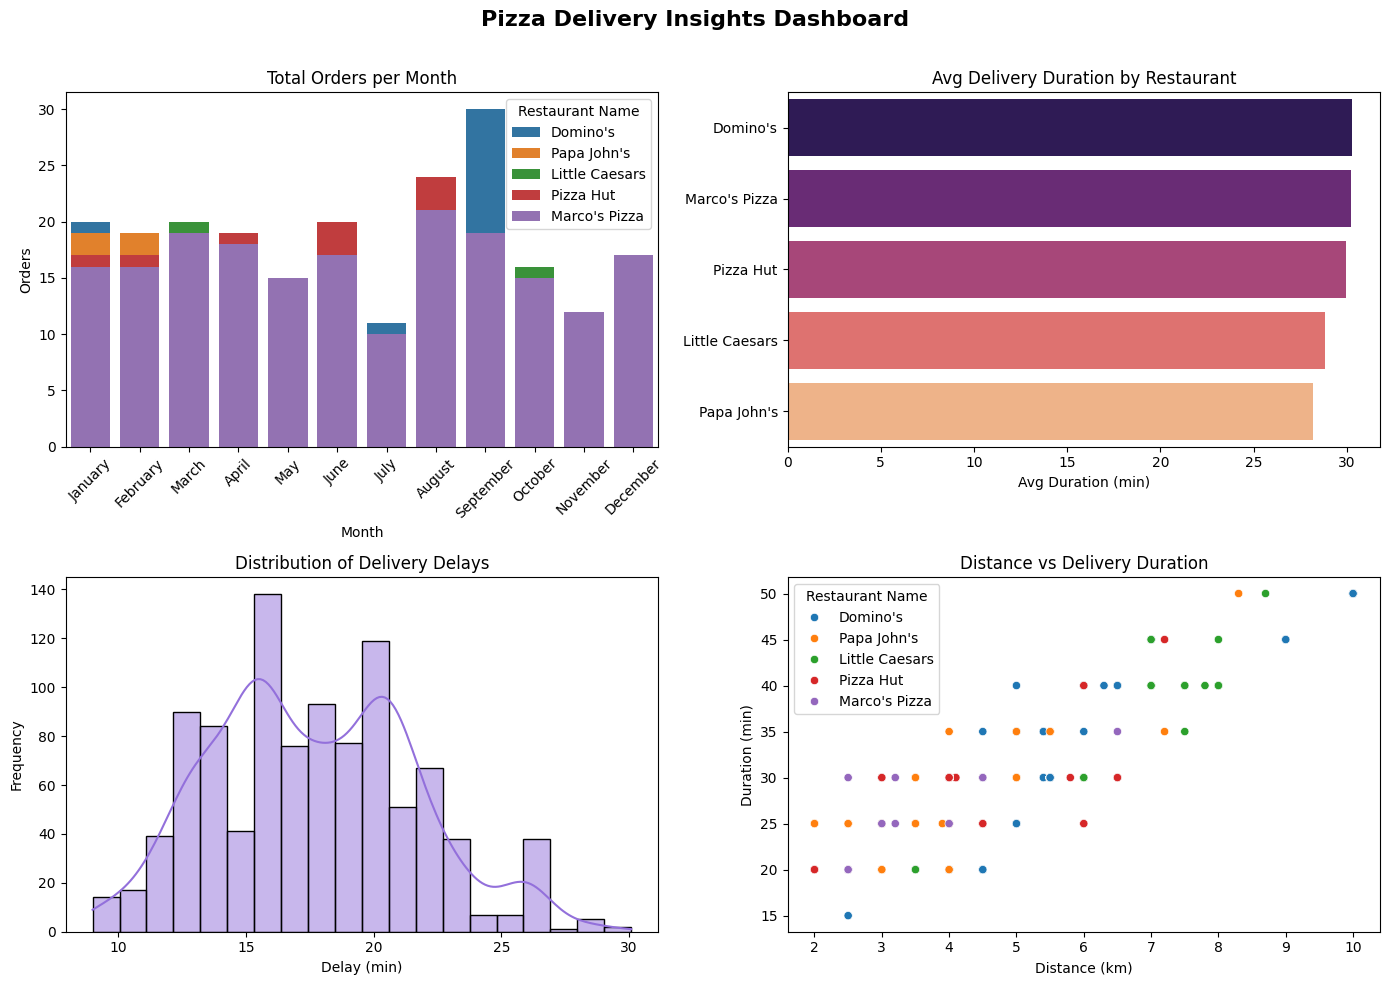

In [ ]:
# Preparar la figura
fig, axes = plt.subplots(2, 2, figsize=(14,10))
plt.suptitle('Pizza Delivery Insights Dashboard', fontsize=16, fontweight='bold')

# Ordenes por mes
sns.countplot(
    data=pizza_data,
    x='Order Month',
    order=[
        'January','February','March','April','May','June',
        'July','August','September','October','November','December'
    ],
    hue = 'Restaurant Name',
    ax=axes[0,0],
    dodge=False
)
axes[0,0].set_title('Total Orders per Month')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Orders')
axes[0,0].tick_params(axis='x', rotation=45)

# Duración promedio de entrega por restaurante
avg_restaurant = (
    pizza_data.groupby('Restaurant Name')['Delivery Duration (min)']
    .mean().reset_index().sort_values(by='Delivery Duration (min)', ascending=False)
)
sns.barplot(
    data=avg_restaurant,
    x='Delivery Duration (min)',
    y = 'Restaurant Name',
    hue='Restaurant Name',
    palette='magma',
    legend = False,
    ax=axes[0,1]
)
axes[0,1].set_title('Avg Delivery Duration by Restaurant')
axes[0,1].set_xlabel('Avg Duration (min)')
axes[0,1].set_ylabel('')

# Distribución de tiempo de entrega
sns.histplot(
    data=pizza_data,
    x='Delay (min)',
    bins=20,
    kde=True,
    color='mediumpurple',
    ax=axes[1,0]
)
axes[1,0].set_title('Distribution of Delivery Delays')
axes[1,0].set_xlabel('Delay (min)')
axes[1,0].set_ylabel('Frequency')

# Distancia VS Duración segmentado por tamaño de pizza
sns.scatterplot(
    data=pizza_data,
    x='Distance (km)',
    y='Delivery Duration (min)',
    hue='Restaurant Name',
    ax=axes[1,1]
)
axes[1,1].set_title('Distance vs Delivery Duration')
axes[1,1].set_xlabel('Distance (km)')
axes[1,1].set_ylabel('Duration (min)')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [ ]:
pizza_data[["Restaurant Name","Delivery Duration (min)",'Distance (km)']]

,Restaurant Name,Delivery Duration (min),Distance (km)
0,Domino's,15,2.5
1,Papa John's,25,5.0
2,Little Caesars,20,3.0
3,Pizza Hut,25,4.5
4,Marco's Pizza,20,2.0
...,...,...,...
999,Domino's,30,5.5
1000,Pizza Hut,30,4.0
1001,Papa John's,30,5.0
1002,Little Caesars,30,6.0


## HeatMap

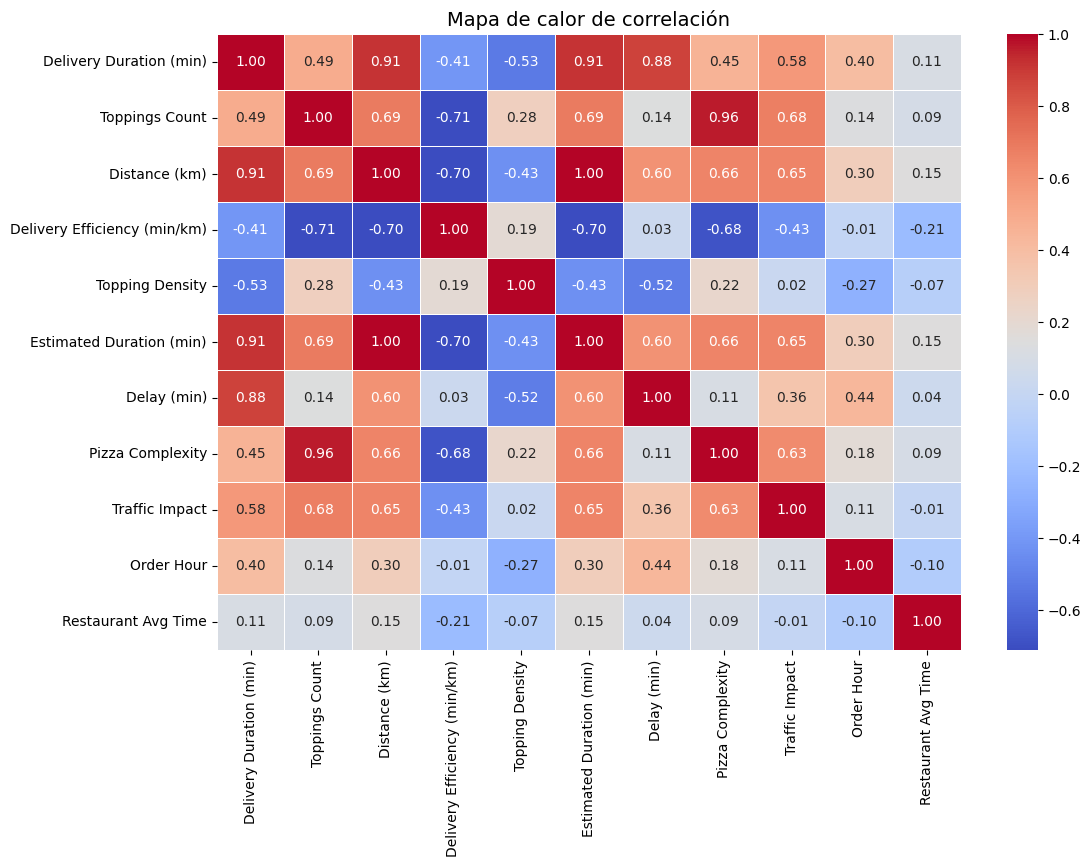

In [ ]:
# Select only numeric columns for correlation
numeric_cols = pizza_data.select_dtypes(include=[np.number]).columns

corr_matrix = pizza_data[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    linewidths=0.5,
    fmt=".2f"
)
plt.title('Mapa de calor de correlación', fontsize=14)
plt.show()


In [ ]:
import plotly.express as px
import pandas as pd

corr_matrix = pizza_data[numeric_cols].corr().round(2)
corr_df = corr_matrix.stack().reset_index()
corr_df.columns = ['Variable 1', 'Variable 2', 'Correlation']

fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    title='Interactive Correlation Heatmap — Pizza Performance Metrics',
    aspect='auto'
)

fig.update_layout(
    width=1200,
    height=1000,
    template='plotly_white',
    title_font=dict(size=18),
    xaxis_title='Variables',
    yaxis_title='Variables',
)
fig.show()


## Folium

### Mapa Base

In [ ]:
import matplotlib.colors as mcolors


# --- Predefined city coordinates ---
city_coords = {
    "New York, NY": (40.7128, -74.0060),
    "Los Angeles, CA": (34.0522, -118.2437),
    "Chicago, IL": (41.8781, -87.6298),
    "Houston, TX": (29.7604, -95.3698),
    "Phoenix, AZ": (33.4484, -112.0740),
    "Philadelphia, PA": (39.9526, -75.1652),
    "San Antonio, TX": (29.4241, -98.4936),
    "San Diego, CA": (32.7157, -117.1611),
    "Dallas, TX": (32.7767, -96.7970),
    "San Jose, CA": (37.3382, -121.8863),
    "Seattle, WA": (47.6062, -122.3321),
    "Miami, FL": (25.7617, -80.1918),
    "Boston, MA": (42.3601, -71.0589),
    "Atlanta, GA": (33.7490, -84.3880),
    "Washington, DC": (38.9072, -77.0369),
    "Denver, CO": (39.7392, -104.9903),
    "Austin, TX": (30.2672, -97.7431),
    "San Francisco, CA": (37.7749, -122.4194),
    "Detroit, MI": (42.3314, -83.0458),
    "Minneapolis, MN": (44.9778, -93.2650),
}

# --- KPI and data prep ---
kpi_col = "Delay (min)"

city_kpi = (
    pizza_data.groupby(["Location", "Restaurant Name"])[kpi_col]
    .mean()
    .reset_index()
)
city_kpi = city_kpi[city_kpi["Location"].isin(city_coords.keys())]
city_kpi

,Location,Restaurant Name,Delay (min)
8,"Atlanta, GA",Domino's,26.000000
9,"Atlanta, GA",Little Caesars,17.065000
10,"Atlanta, GA",Marco's Pizza,14.309091
11,"Atlanta, GA",Pizza Hut,20.231034
13,"Austin, TX",Domino's,21.333333
...,...,...,...
176,"Seattle, WA",Papa John's,15.640000
177,"Seattle, WA",Pizza Hut,18.640000
189,"Washington, DC",Domino's,23.400000
190,"Washington, DC",Little Caesars,23.200000


In [ ]:
restaurants = city_kpi["Restaurant Name"].unique()
cmap = plt.get_cmap("viridis", len(restaurants))
color_map = {r: mcolors.to_hex(cmap(i)) for i, r in enumerate(restaurants)}

In [ ]:
m2 = folium.Map(location=[39.5, -98.35], zoom_startfolium=4)

for _, row in city_kpi.iterrows():
    lat, lon = city_coords[row["Location"]]
    color = color_map[row["Restaurant Name"]]
    folium.CircleMarker(
        location=(lat, lon),
        radius=6,
        color=color,
        fill=True,
        popup=folium.Popup(
            f"""
            <b>Restaurant:</b> {row['Restaurant Name']}<br>
            <b>City:</b> {row['Location']}<br>
            <b>{kpi_col}:</b> {row[kpi_col]:.1f} min
            """,
            max_width=250,
        ),
    ).add_to(m2)

m2


### Choropleth

In [ ]:
city_kpi["State"] = city_kpi["Location"].str.extract(r",\s*([A-Z]{2})")

# --- Map state abbreviations → full names ---
abbr_to_name = {
    'AL':'Alabama','AK':'Alaska','AZ':'Arizona','AR':'Arkansas','CA':'California','CO':'Colorado',
    'CT':'Connecticut','DE':'Delaware','FL':'Florida','GA':'Georgia','HI':'Hawaii','ID':'Idaho',
    'IL':'Illinois','IN':'Indiana','IA':'Iowa','KS':'Kansas','KY':'Kentucky','LA':'Louisiana',
    'ME':'Maine','MD':'Maryland','MA':'Massachusetts','MI':'Michigan','MN':'Minnesota',
    'MS':'Mississippi','MO':'Missouri','MT':'Montana','NE':'Nebraska','NV':'Nevada',
    'NH':'New Hampshire','NJ':'New Jersey','NM':'New Mexico','NY':'New York',
    'NC':'North Carolina','ND':'North Dakota','OH':'Ohio','OK':'Oklahoma','OR':'Oregon',
    'PA':'Pennsylvania','RI':'Rhode Island','SC':'South Carolina','SD':'South Dakota',
    'TN':'Tennessee','TX':'Texas','UT':'Utah','VT':'Vermont','VA':'Virginia','WA':'Washington',
    'WV':'West Virginia','WI':'Wisconsin','WY':'Wyoming','DC':'District of Columbia'
}
city_kpi["State_Name"] = city_kpi["State"].map(abbr_to_name)
city_kpi


,Location,Restaurant Name,Delay (min),State,State_Name
8,"Atlanta, GA",Domino's,26.000000,GA,Georgia
9,"Atlanta, GA",Little Caesars,17.065000,GA,Georgia
10,"Atlanta, GA",Marco's Pizza,14.309091,GA,Georgia
11,"Atlanta, GA",Pizza Hut,20.231034,GA,Georgia
13,"Austin, TX",Domino's,21.333333,TX,Texas
...,...,...,...,...,...
176,"Seattle, WA",Papa John's,15.640000,WA,Washington
177,"Seattle, WA",Pizza Hut,18.640000,WA,Washington
189,"Washington, DC",Domino's,23.400000,DC,District of Columbia
190,"Washington, DC",Little Caesars,23.200000,DC,District of Columbia


In [ ]:

# --- Load US States GeoJSON ---
with urlopen("https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json") as f:
    states_geo = json.load(f)

# --- Create Map ---
m = folium.Map(location=[39, -98], zoom_start=4, tiles="cartodb positron")

# --- Choropleth ---
folium.Choropleth(
    geo_data=states_geo,
    name="choropleth",
    data=city_kpi,
    columns=["State", "Delay (min)"],
    key_on="feature.id",  # feature.id in GeoJSON = full state name
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.3,
    legend_name="Average Delay (min)	)",
    nan_fill_color="lightgray"
).add_to(m)

folium.LayerControl().add_to(m)

m.save("US_pizza_delivery_choropleth.html")
m
